In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Advanced Models
import xgboost as xgb
import lightgbm as lgb
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv("/content/capstoneproject.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


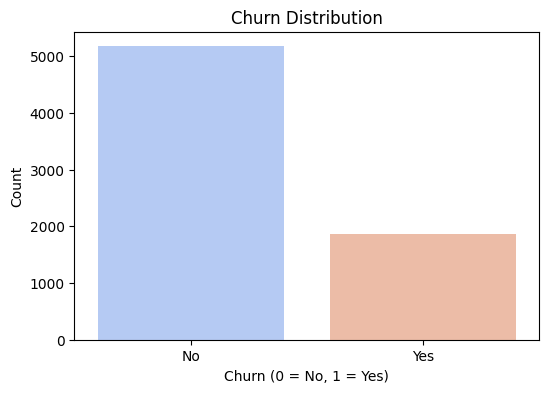

In [3]:
%matplotlib inline
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, hue="Churn", palette="coolwarm", legend=False)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

DATA EXPLORATION AND PREPROCESSING

Get dataset information

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Check for missing values

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.shape

(7043, 21)

 Convert TotalCharges to Numeric & Handle Missing Values

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [9]:
df = df.dropna()

In [10]:
df.shape

(7032, 21)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print('shape before deleting duplicate values',df.shape)

shape before deleting duplicate values (7032, 21)


In [13]:
df=df.drop_duplicates()
print('shape after deleting duplicate values',df.shape)

shape after deleting duplicate values (7032, 21)


In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Basic Statistics of Numerical Columns

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
# printing unique values in all the columns
numerical_feature_list=['tenure','MonthlyCharges','TotalCharges']
for col in df.columns:
  if col not in numerical_feature_list:
   print(col)
   print(df[col].unique())

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender
['Female' 'Male']
SeniorCitizen
[0 1]
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


In [17]:
#checking distribution of target variable-churn
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


Drop unnecessary columns

In [18]:
df.drop(columns=["customerID"], inplace=True)

In [19]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [20]:
df['gender'].replace({'Female':1,'Male':0},inplace=True)
df['gender'].unique()

<ipython-input-20-c62ae2747b18>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'Female':1,'Male':0},inplace=True)
<ipython-input-20-c62ae2747b18>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace({'Female':1,'Male':0},inplace=True)


array([1, 0])

In [21]:
# get all the unique values cols of data
def print_unique_col_values(df):
  for column in df:
    if df[column].dtypes=='object':
      print(f'{column}:{df[column].unique()}')

In [22]:
print_unique_col_values(df)

Partner:['Yes' 'No']
Dependents:['No' 'Yes']
PhoneService:['No' 'Yes']
MultipleLines:['No phone service' 'No' 'Yes']
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:['No' 'Yes' 'No internet service']
OnlineBackup:['Yes' 'No' 'No internet service']
DeviceProtection:['No' 'Yes' 'No internet service']
TechSupport:['No' 'Yes' 'No internet service']
StreamingTV:['No' 'Yes' 'No internet service']
StreamingMovies:['No' 'Yes' 'No internet service']
Contract:['Month-to-month' 'One year' 'Two year']
PaperlessBilling:['Yes' 'No']
PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [23]:
df.replace('No internet service','No',inplace=True)
df.replace('No phone service', 'No',inplace=True)

In [24]:
binary_cols = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

Exploratory Data Analysis (EDA)

Univariate Analysis

In [25]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


🔹 Churn Distribution

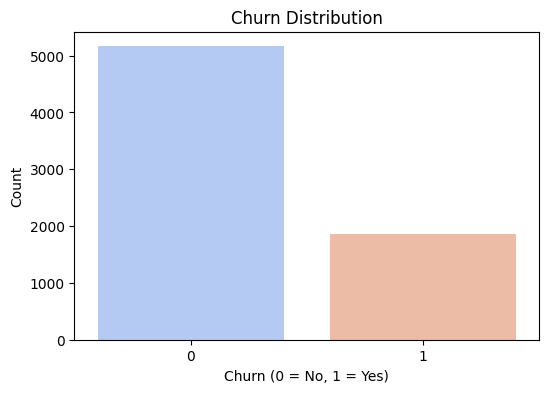

In [26]:
%matplotlib inline
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, hue="Churn", palette="coolwarm", legend=False)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

🔹 Tenure Distribution

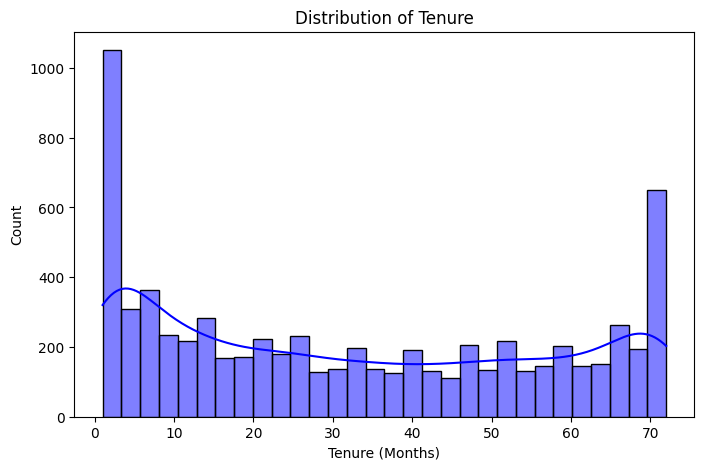

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tenure"], bins=30, kde=True, color="blue")
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.show()

🔹 Monthly Charges Distribution

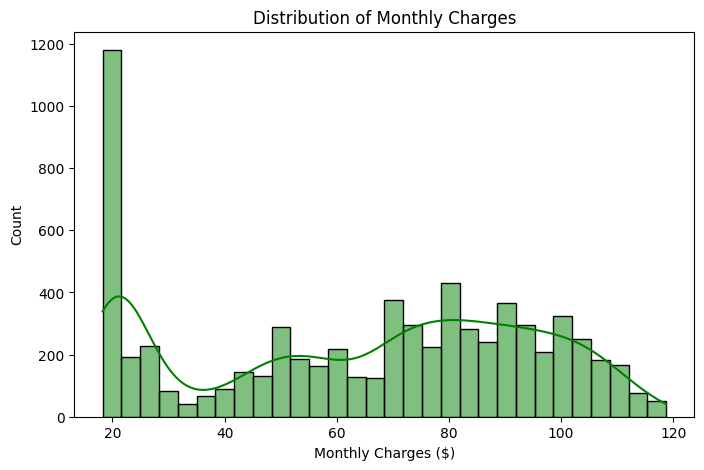

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="green")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.show()


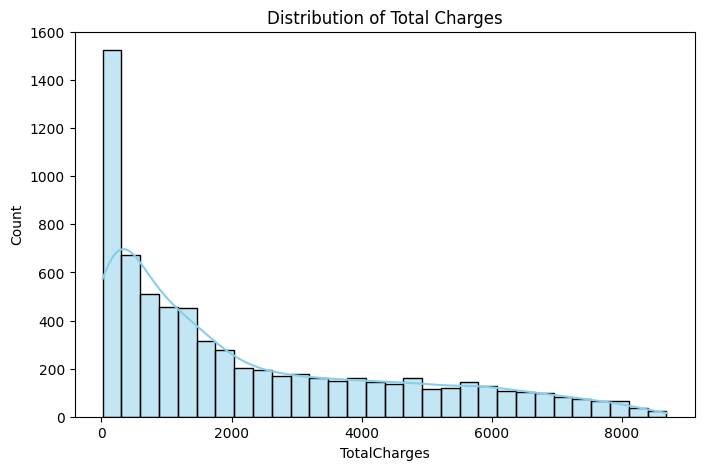

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalCharges'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Total Charges")
plt.xlabel("TotalCharges")
plt.show()

 Bivariate Analysis

🔹 Churn vs. Monthly Charges

<ipython-input-30-f1badbdc729a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="coolwarm")


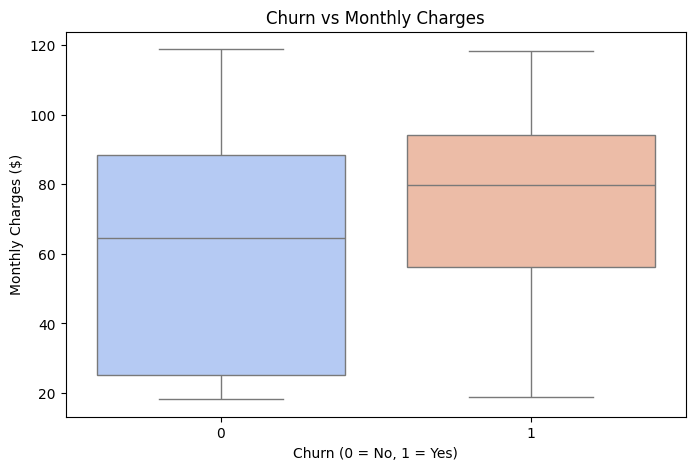

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="coolwarm")
plt.title("Churn vs Monthly Charges")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges ($)")
plt.show()


🔹 Churn Rate by Contract Type

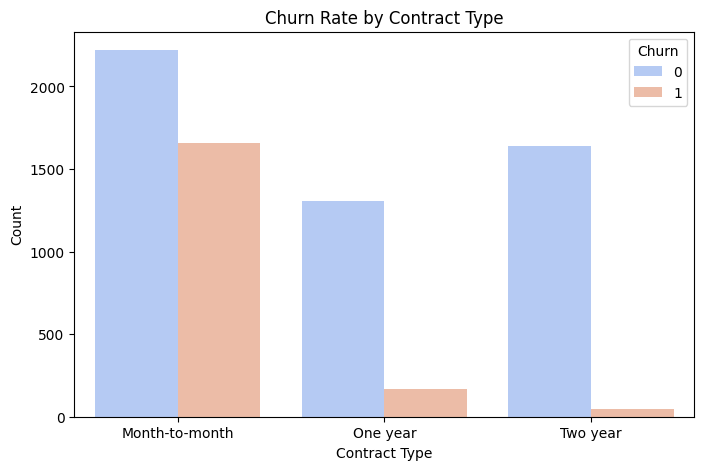

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="coolwarm")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()



🔹 Churn by Internet Service



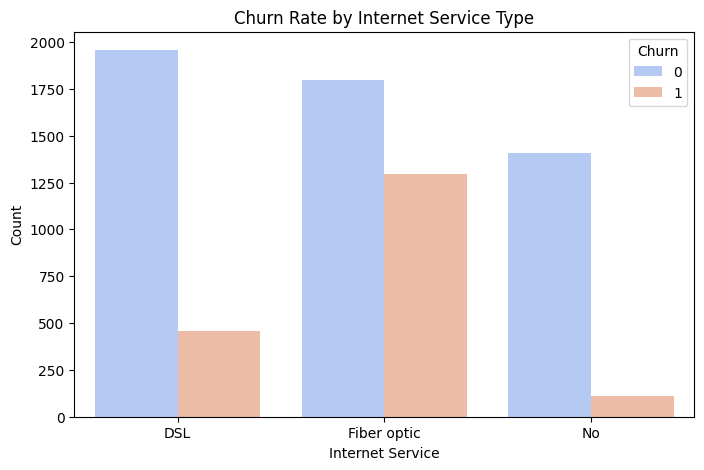

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(x="InternetService", hue="Churn", data=df, palette="coolwarm")
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.show()


🔹Churn by Payment Method

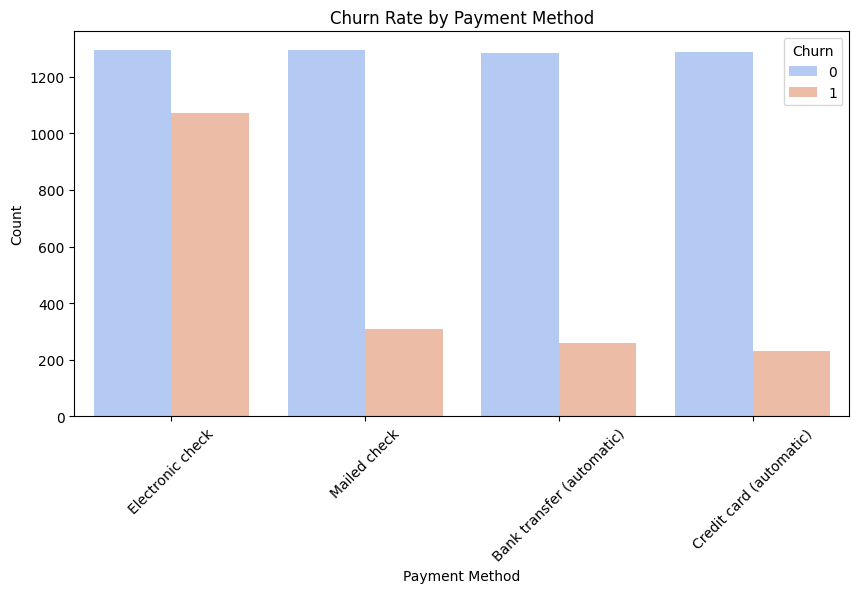

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()


🔹Churn by Streaming Services (TV & Movies)

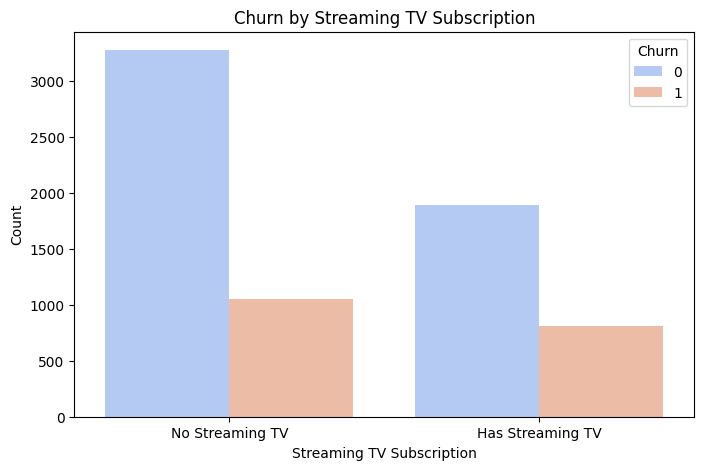

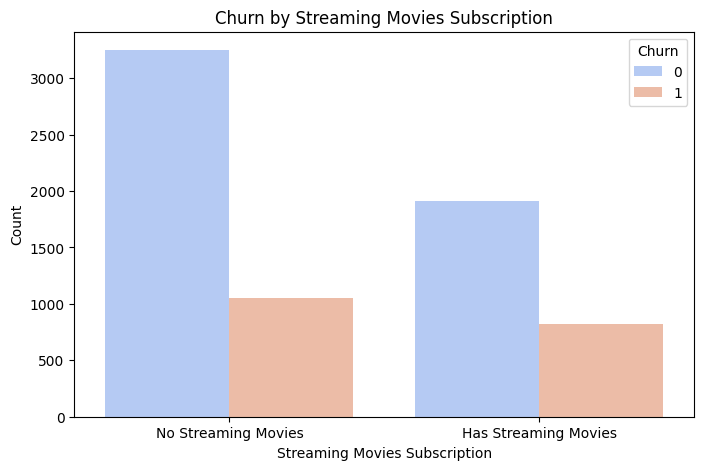

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(x="StreamingTV", hue="Churn", data=df, palette="coolwarm")
plt.title("Churn by Streaming TV Subscription")
plt.xlabel("Streaming TV Subscription")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Streaming TV", "Has Streaming TV"])  # Add Labels
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="StreamingMovies", hue="Churn", data=df, palette="coolwarm")
plt.title("Churn by Streaming Movies Subscription")
plt.xlabel("Streaming Movies Subscription")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Streaming Movies", "Has Streaming Movies"])  # Add Labels
plt.show()


🔹Churn by Senior Citizen Status

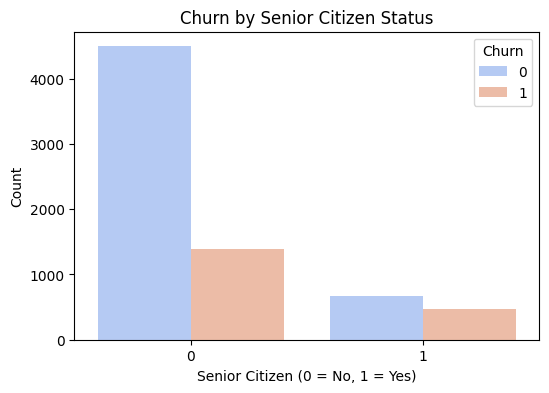

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df, palette="coolwarm")
plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


🔹Churn vs. Tenure

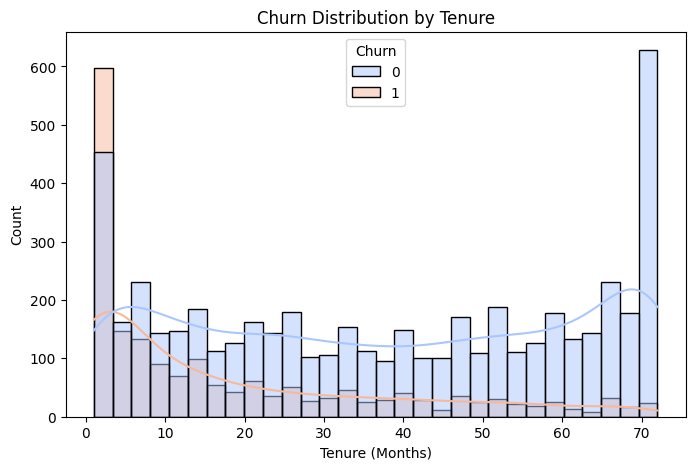

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, bins=30, palette="coolwarm")
plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()


🔹 Churn vs. Monthly Charges

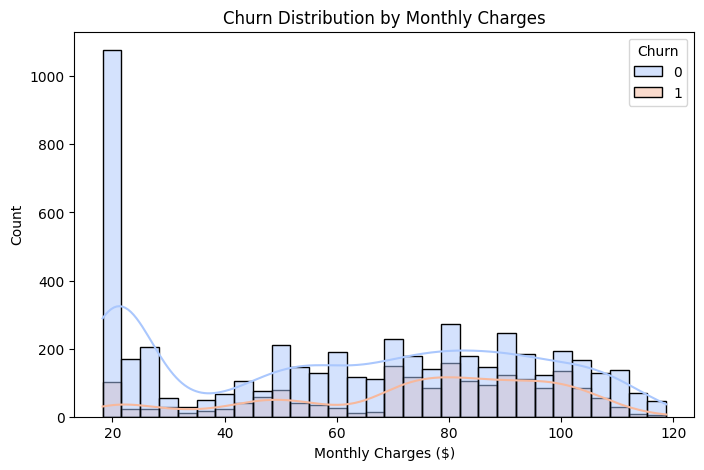

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, bins=30, palette="coolwarm")
plt.title("Churn Distribution by Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.show()


🔹Churn vs. Total Charges

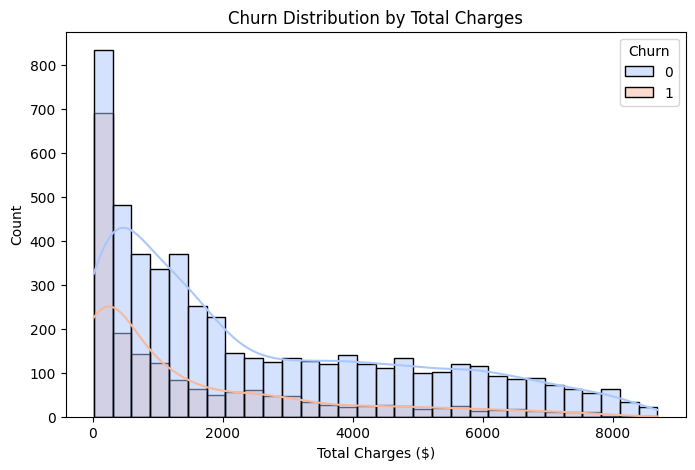

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="TotalCharges", hue="Churn", kde=True, bins=30,  palette="coolwarm")
plt.title("Churn Distribution by Total Charges")
plt.xlabel("Total Charges ($)")
plt.ylabel("Count")
plt.show()


Tenure KDE Plot

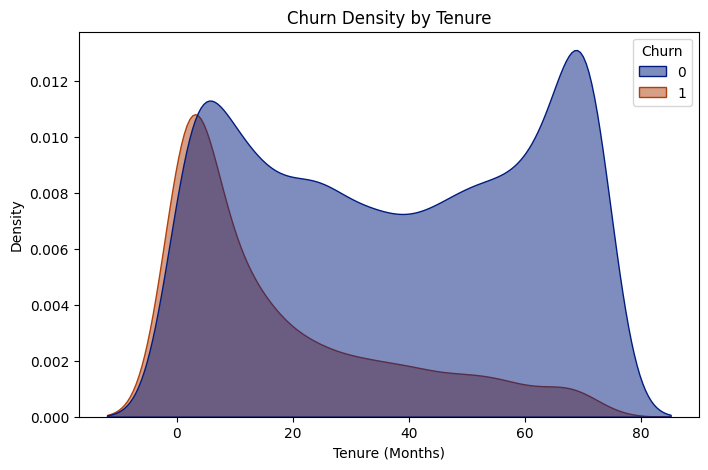

In [39]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True,  palette="dark",alpha=0.5)
plt.title("Churn Density by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.show()


Monthly Charges KDE Plot

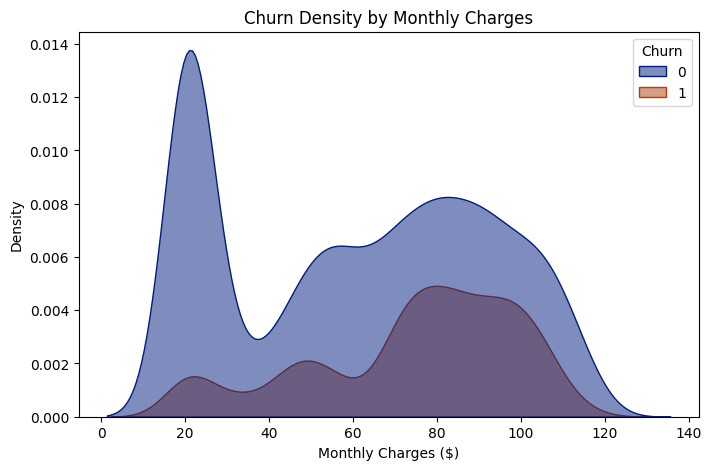

In [40]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, palette="dark",alpha=0.5)
plt.title("Churn Density by Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.show()


Total Charges KDE Plot

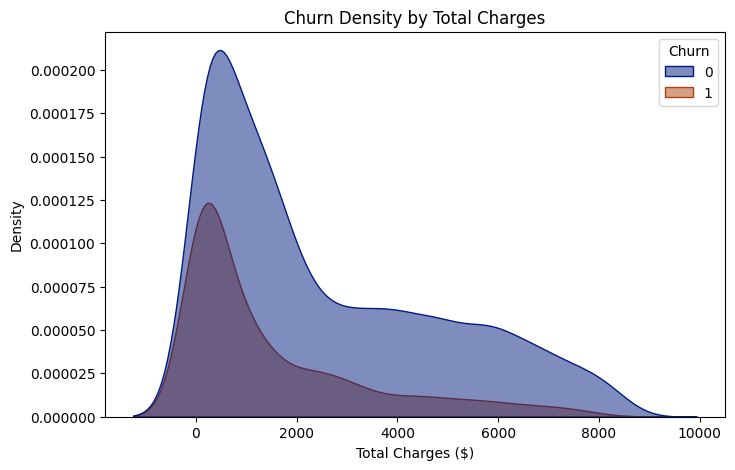

In [41]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", fill=True,  palette="dark",alpha=0.5)
plt.title("Churn Density by Total Charges")
plt.xlabel("Total Charges ($)")
plt.ylabel("Density")
plt.show()


Correlation Matrix & Heatmap

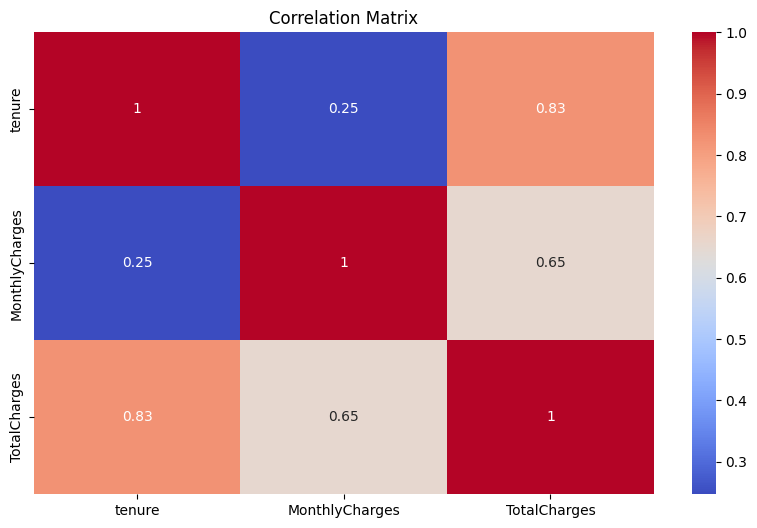

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Encode Categorical Features

In [43]:
from sklearn.preprocessing import LabelEncoder



final = pd.get_dummies(df, columns=["Contract", "InternetService", "PaymentMethod"], drop_first=True)

# Verify encoding
print(final.head())


   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       1             0   
1       0              0        0           0      34             1   
2       0              0        0           0       2             1   
3       0              0        0           0      45             0   
4       1              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              0               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              0               1             0                 1  ...   
4              0               0             0                 0  ...   

   MonthlyCharges  TotalCharges  Churn  Contract_One year  Contract_Two year  \
0           29.85         29.85      0              Fa

In [44]:
final.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


In [45]:
# Convert dummy columns from uint8 to int64 (or another numeric type)
dummy_cols = [col for col in final.columns if col.startswith(('Contract_', 'InternetService_', 'PaymentMethod_'))]
final[dummy_cols] = final[dummy_cols].astype(int)
final.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


In [46]:
final.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0


In [47]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Apply StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(final[num_features])

# Verify scaling
print(final.head())


   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       1             0   
1       0              0        0           0      34             1   
2       0              0        0           0       2             1   
3       0              0        0           0      45             0   
4       1              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              0               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              0               1             0                 1  ...   
4              0               0             0                 0  ...   

   MonthlyCharges  TotalCharges  Churn  Contract_One year  Contract_Two year  \
0           29.85         29.85      0                

Splitting Data

In [48]:
from sklearn.model_selection import train_test_split
x=final.drop('Churn',axis=1)
y=final['Churn']
#split data into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((5625, 23), (1407, 23), (5625,), (1407,))

Check Class Distribution

<ipython-input-49-b50df0fb75ad>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=final, palette="coolwarm")


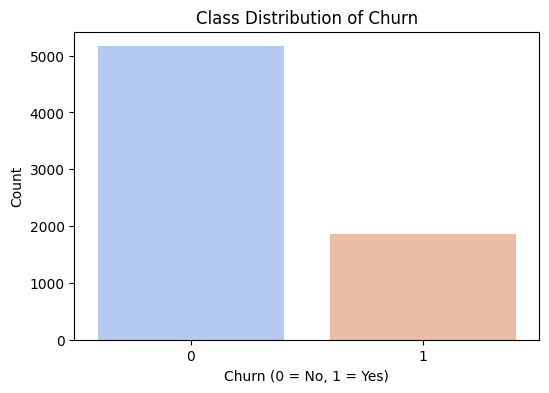

Churn Class Distribution:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [49]:
# Count the number of instances in each class
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=final, palette="coolwarm")
plt.title("Class Distribution of Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Print percentage of each class
churn_counts = final["Churn"].value_counts(normalize=True) * 100
print(f"Churn Class Distribution:\n{churn_counts}")


Handling Class Imbalance (If Needed)

1️⃣ Oversample the minority class using SMOTE

2️⃣ Undersample the majority class

In [50]:
from imblearn.over_sampling import SMOTE



# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x, y)

# Verify the new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)



Class distribution after SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


<ipython-input-51-12547675249a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="coolwarm")


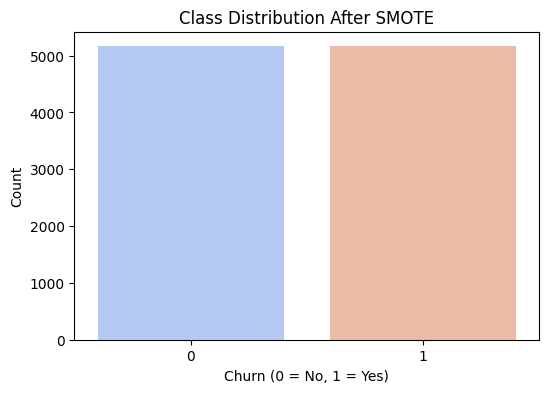

In [51]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, palette="coolwarm")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [52]:
# Step 1: SMOTE for class balancing
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Assume x and y are already defined
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x, y)

# Optional: Check class balance after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)

# Step 2: Feature selection (Select top 10 features)
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_resampled, y_resampled)
# Get the column names of the selected features
selected_feature_names = x.columns[selector.get_support()]
print("Top 10 selected features:")
print(selected_feature_names)

# Step 3: Split the balanced and selected data
x_train, x_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42)

Class distribution after SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64
Top 10 selected features:
Index(['Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'TechSupport',
       'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic',
       'InternetService_No', 'PaymentMethod_Credit card (automatic)'],
      dtype='object')


In [53]:
X_selected

array([[ 1.,  0.,  1., ...,  0.,  0.,  0.],
       [ 0.,  0., 34., ...,  0.,  0.,  0.],
       [ 0.,  0.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  2., ...,  1.,  0.,  0.],
       [ 0.,  0., 31., ...,  1.,  0.,  0.]])

Model Creation

🔹 Logistic Regression

In [54]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
y_pred = logreg.predict(x_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.8102613746369797
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.81      2066
   macro avg       0.81      0.81      0.81      2066
weighted avg       0.81      0.81      0.81      2066



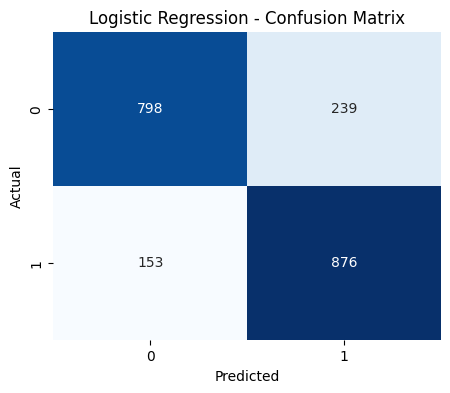

In [55]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 Decision Tree

In [56]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.7850919651500484
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1037
           1       0.77      0.82      0.79      1029

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.78      2066
weighted avg       0.79      0.79      0.78      2066



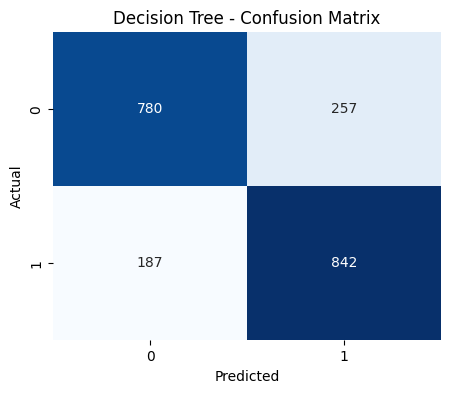

In [57]:
cm_dt = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 Random Forest

In [58]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.7947725072604066
              precision    recall  f1-score   support

           0       0.82      0.75      0.79      1037
           1       0.77      0.84      0.80      1029

    accuracy                           0.79      2066
   macro avg       0.80      0.79      0.79      2066
weighted avg       0.80      0.79      0.79      2066



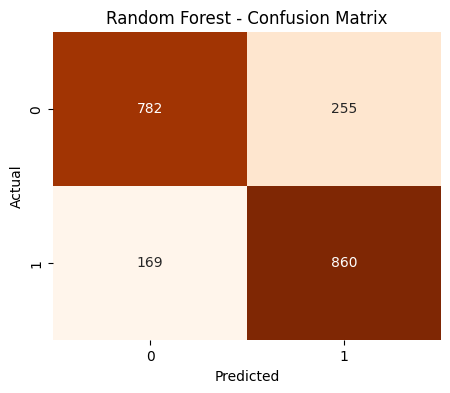

In [59]:
cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 XGBoost

In [60]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


XGBoost Accuracy: 0.8112294288480155
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.81      2066
   macro avg       0.81      0.81      0.81      2066
weighted avg       0.81      0.81      0.81      2066



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:50:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


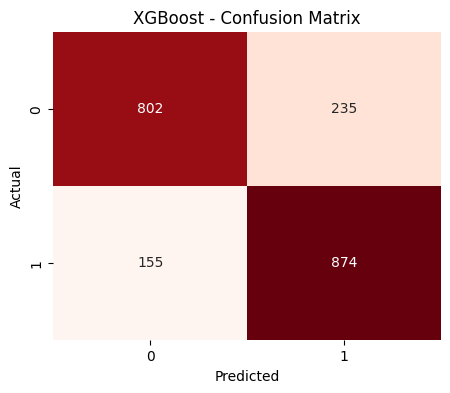

In [61]:
cm_xgb = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 LightGBM

In [62]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(x_train, y_train)
y_pred = lgb_model.predict(x_test)
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 4134, number of negative: 4126
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500484 -> initscore=0.001937
[LightGBM] [Info] Start training from score 0.001937
LightGBM Accuracy: 0.8151016456921588
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.82      2066
   macro avg       0.82      0.82      0.81      2066
weighted avg       0.82      0.82      0.81      2066



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


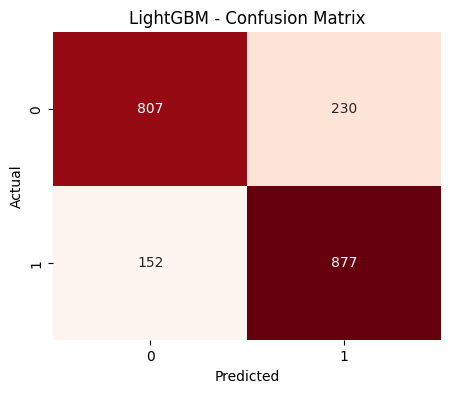

In [63]:
cm_lgb = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 K-Nearest Neighbors (KNN)

In [64]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


KNN Accuracy: 0.7899322362052275
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1037
           1       0.75      0.87      0.81      1029

    accuracy                           0.79      2066
   macro avg       0.80      0.79      0.79      2066
weighted avg       0.80      0.79      0.79      2066



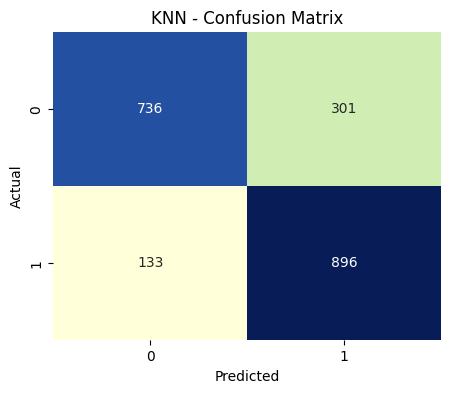

In [65]:
cm_knn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 Support Vector Machine (SVM)

In [66]:
svm = SVC(probability=True)
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


SVM Accuracy: 0.7744433688286544
              precision    recall  f1-score   support

           0       0.81      0.71      0.76      1037
           1       0.74      0.84      0.79      1029

    accuracy                           0.77      2066
   macro avg       0.78      0.77      0.77      2066
weighted avg       0.78      0.77      0.77      2066



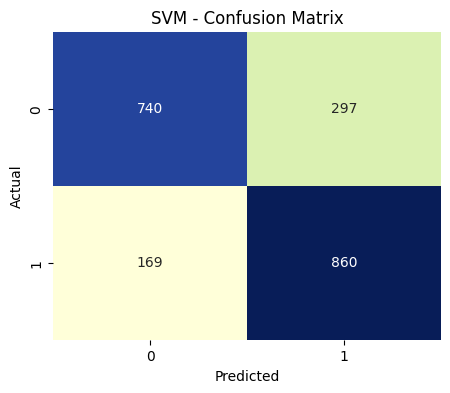

In [67]:
cm_svm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🔹 Naive Bayes

In [68]:
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Naive Bayes Accuracy: 0.8049370764762827
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1037
           1       0.79      0.84      0.81      1029

    accuracy                           0.80      2066
   macro avg       0.81      0.81      0.80      2066
weighted avg       0.81      0.80      0.80      2066



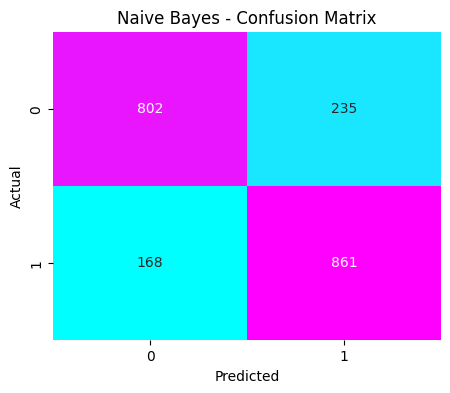

In [69]:
cm_nb = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="cool", cbar=False)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbm.fit(x_train,y_train)

y_pred = gbm.predict(x_test)
print("GBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


GBM Accuracy: 0.8117134559535334
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.81      2066
   macro avg       0.81      0.81      0.81      2066
weighted avg       0.81      0.81      0.81      2066



 Build & Train an Artificial Neural Network (ANN)

In [71]:
# Define ANN architecture
model = Sequential([
    Dense(32, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"ANN Test Accuracy: {accuracy:.4f}")


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6424 - loss: 0.6242 - val_accuracy: 0.7977 - val_loss: 0.4634
Epoch 2/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8100 - loss: 0.4341 - val_accuracy: 0.8098 - val_loss: 0.4452
Epoch 3/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8041 - loss: 0.4334 - val_accuracy: 0.8141 - val_loss: 0.4516
Epoch 4/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8133 - loss: 0.4251 - val_accuracy: 0.8103 - val_loss: 0.4404
Epoch 5/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8025 - loss: 0.4349 - val_accuracy: 0.8127 - val_loss: 0.4542
Epoch 6/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8060 - loss: 0.4338 - val_accuracy: 0.8132 - val_loss: 0.4382
Epoch 7/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8101 - loss: 0.4247 - val_accuracy: 0.8103 - val_loss: 0.4576
Epoch 8/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8075 - loss: 0.4290 - val_accuracy: 0.8001 - val_

Compare Model Performances

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-72-bb26d62743ec>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


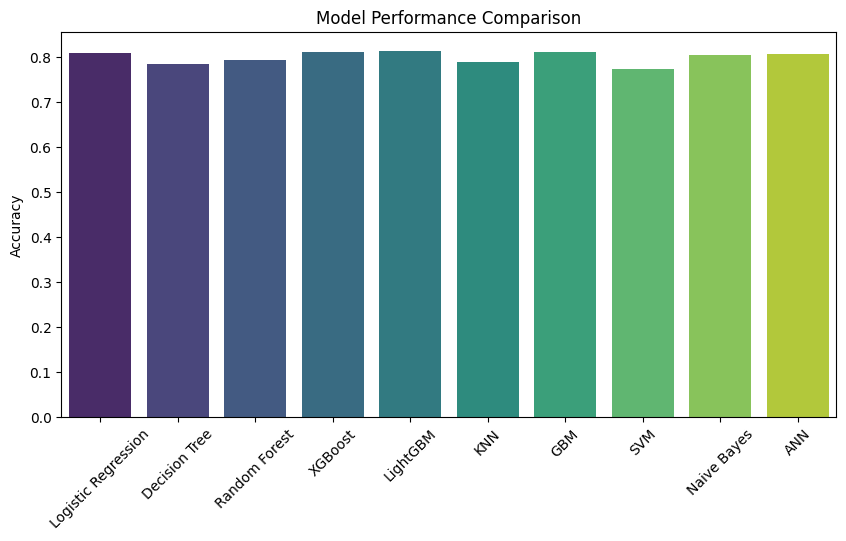

In [72]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM", "KNN","GBM", "SVM", "Naive Bayes", "ANN"]
accuracies = [accuracy_score(y_test, logreg.predict(x_test)),
              accuracy_score(y_test, dt.predict(x_test)),
              accuracy_score(y_test, rf.predict(x_test)),
              accuracy_score(y_test, xgb_model.predict(x_test)),
              accuracy_score(y_test, lgb_model.predict(x_test)),
              accuracy_score(y_test, knn.predict(x_test)),
              accuracy_score(y_test, gbm.predict(x_test)),
              accuracy_score(y_test, svm.predict(x_test)),
              accuracy_score(y_test, nb.predict(x_test)),
              accuracy]

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()


In [73]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb

# 1. Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid=param_grid_rf, scoring='roc_auc', cv=5, n_jobs=-1)
grid_rf.fit(x_train, y_train)

# 2. Gradient Boosting (GBM)
param_grid_gbm = {
    'n_estimators': [100, 150],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}
grid_gbm = GridSearchCV(GradientBoostingClassifier(random_state=42),
                        param_grid=param_grid_gbm, scoring='roc_auc', cv=5, n_jobs=-1)
grid_gbm.fit(x_train, y_train)

# 3. LightGBM
param_grid_lgb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    'max_depth': [-1, 10],
    'subsample': [0.8, 1.0]
}
grid_lgb = GridSearchCV(lgb.LGBMClassifier(random_state=42),
                        param_grid=param_grid_lgb, scoring='roc_auc', cv=5, n_jobs=-1)
grid_lgb.fit(x_train, y_train)

# 4. XGBoost
param_grid_xgb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
                        param_grid=param_grid_xgb, scoring='roc_auc', cv=5, n_jobs=-1)
grid_xgb.fit(x_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 4134, number of negative: 4126
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500484 -> initscore=0.001937
[LightGBM] [Info] Start training from score 0.001937


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:53:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 150], 'subsample': [0.8, 1.0]},
             scoring='roc_auc')

In [74]:
# Evaluate the best estimators
tuned_models = {
    "Tuned Random Forest": grid_rf.best_estimator_,
    "Tuned Gradient Boosting": grid_gbm.best_estimator_,
    "Tuned LightGBM": grid_lgb.best_estimator_,
    "Tuned XGBoost": grid_xgb.best_estimator_
}

for name, model in tuned_models.items():
    y_pred = model.predict(x_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Tuned Random Forest
Accuracy: 0.814133591481123
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.81      2066
   macro avg       0.82      0.81      0.81      2066
weighted avg       0.82      0.81      0.81      2066


Tuned Gradient Boosting
Accuracy: 0.8102613746369797
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1037
           1       0.79      0.85      0.82      1029

    accuracy                           0.81      2066
   macro avg       0.81      0.81      0.81      2066
weighted avg       0.81      0.81      0.81      2066


Tuned LightGBM
Accuracy: 0.8112294288480155
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1037
           1       0.79      0.84      0.82      1029

    accuracy                      

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [75]:
# Updated Dictionary with Tuned Models
models = {
    "Logistic Regression": logreg,                      # Original
    "Decision Tree": dt,                                # Original
    "Random Forest": grid_rf.best_estimator_,           # Tuned
    "XGBoost": grid_xgb.best_estimator_,                # Tuned
    "LightGBM": grid_lgb.best_estimator_,               # Tuned
    "KNN": knn,                                          # Original
    "Gradient Boosting": grid_gbm.best_estimator_,      # Tuned
    "SVM": svm,                                          # Original
    "Naive Bayes": nb                                    # Original
}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-76-02b4abd8ce0d>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


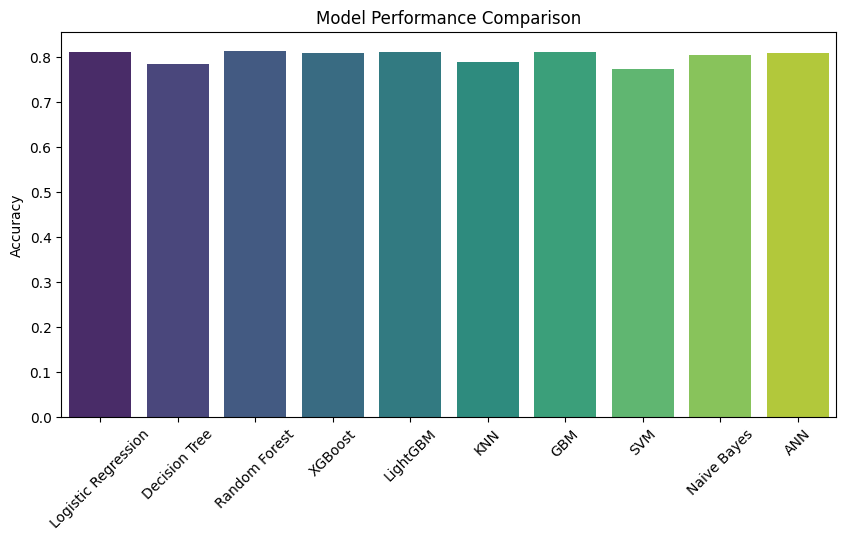

In [76]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM", "KNN","GBM", "SVM", "Naive Bayes", "ANN"]
accuracies = [accuracy_score(y_test, logreg.predict(x_test)),
              accuracy_score(y_test, dt.predict(x_test)),
              accuracy_score(y_test, grid_rf.best_estimator_.predict(x_test)),
              accuracy_score(y_test, grid_xgb.best_estimator_.predict(x_test)),
              accuracy_score(y_test, grid_lgb.best_estimator_.predict(x_test)),
              accuracy_score(y_test, knn.predict(x_test)),
              accuracy_score(y_test, grid_gbm.best_estimator_.predict(x_test)),
              accuracy_score(y_test, svm.predict(x_test)),
              accuracy_score(y_test, nb.predict(x_test)),
              accuracy]

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


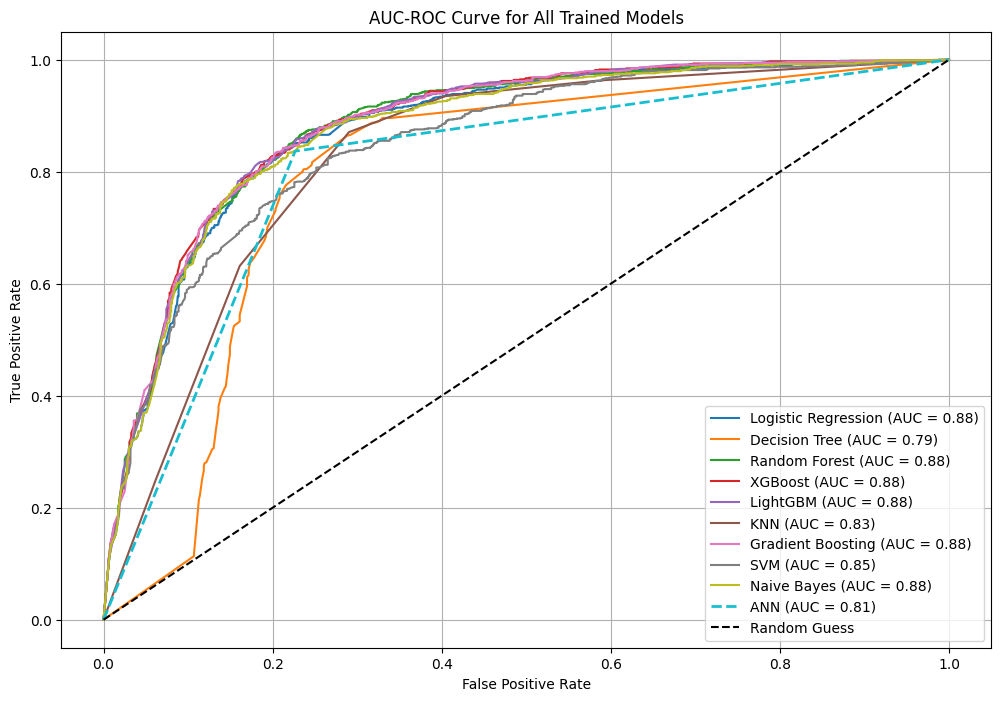

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Dictionary of all your trained models
# Updated Dictionary with Tuned Models
models = {
    "Logistic Regression": logreg,                      # Original
    "Decision Tree": dt,                                # Original
    "Random Forest": grid_rf.best_estimator_,           # Tuned
    "XGBoost": grid_xgb.best_estimator_,                # Tuned
    "LightGBM": grid_lgb.best_estimator_,               # Tuned
    "KNN": knn,                                          # Original
    "Gradient Boosting": grid_gbm.best_estimator_,      # Tuned
    "SVM": svm,                                          # Original
    "Naive Bayes": nb                                    # Original
}


# Plot ROC for each model
for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot for ANN (Keras)
y_probs_ann = model.predict(x_test).ravel()  # Keras model is named `model`
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_probs_ann)
roc_auc_ann = auc(fpr_ann, tpr_ann)
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {roc_auc_ann:.2f})", linestyle='--', linewidth=2)

# Final plot styling
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve for All Trained Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


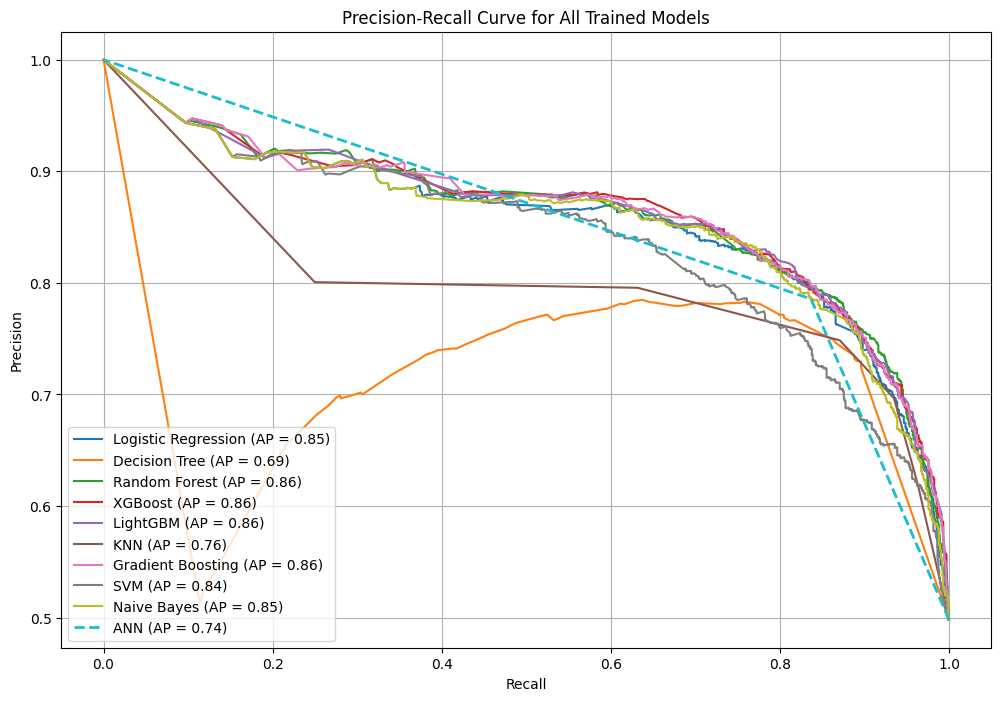

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot PR curve for each model
for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    avg_precision = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.2f})")

# PR curve for ANN (Keras)
y_probs_ann = model.predict(x_test).ravel()
precision_ann, recall_ann, _ = precision_recall_curve(y_test, y_probs_ann)
avg_precision_ann = average_precision_score(y_test, y_probs_ann)
plt.plot(recall_ann, precision_ann, label=f"ANN (AP = {avg_precision_ann:.2f})", linestyle='--', linewidth=2)

# Final plot setup
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for All Trained Models")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Create an empty DataFrame to store results
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])

# Evaluate sklearn models
for name, model in models.items():
    if name != "ANN":
        y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Create an empty DataFrame to store results
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])

# Evaluate sklearn models
for name, model in models.items():
    if name != "ANN":
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]

        results = pd.concat([results, pd.DataFrame([{
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_prob)
        }])], ignore_index=True)

# Evaluate ANN separately
y_pred_ann = (model.predict(x_test) > 0.5).astype("int32")
y_prob_ann = model.predict(x_test).ravel()

results = pd.concat([results, pd.DataFrame([{
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred_ann),
    "Precision": precision_score(y_test, y_pred_ann),
    "Recall": recall_score(y_test, y_pred_ann),
    "F1-Score": f1_score(y_test, y_pred_ann),
    "AUC": roc_auc_score(y_test, y_prob_ann)
}])], ignore_index=True)

# Round for readability
results[["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]] = results[["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]].round(3)

# Sort by AUC (or F1 if preferred)
results = results.sort_values(by="AUC", ascending=False).reset_index(drop=True)

# Display results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Create an empty DataFrame to store results
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])

# Evaluate sklearn models
for name, model in models.items():
    if name != "ANN":
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]

        results = pd.concat([results, pd.DataFrame([{
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_prob)
        }])], ignore_index=True)

# Evaluate ANN separately
y_pred_ann = (model.predict(x_test) > 0.5).astype("int32")
y_prob_ann = model.predict(x_test).ravel()

results = pd.concat([results, pd.DataFrame([{
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred_ann),
    "Precision": precision_score(y_test, y_pred_ann),
    "Recall": recall_score(y_test, y_pred_ann),
    "F1-Score": f1_score(y_test, y_pred_ann),
    "AUC": roc_auc_score(y_test, y_prob_ann)
}])], ignore_index=True)

# Round for readability
results[["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]] = results[["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]].round(3)

# Sort by AUC (or F1 if preferred)
results = results.sort_values(by="AUC", ascending=False).reset_index(drop=True)

# Display results
print("Model Evaluation Summary:")
print(results)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-79-a5a186699395>:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([{
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<ipython-input-79-a5a186699395>:64: F

Model Evaluation Summary:
                 Model  Accuracy  Precision  Recall  F1-Score    AUC
0              XGBoost     0.810      0.785   0.851     0.817  0.884
1        Random Forest     0.814      0.792   0.850     0.820  0.883
2             LightGBM     0.811      0.793   0.840     0.816  0.883
3    Gradient Boosting     0.810      0.788   0.847     0.816  0.883
4  Logistic Regression     0.810      0.786   0.851     0.817  0.876
5          Naive Bayes     0.805      0.786   0.837     0.810  0.875
6                  SVM     0.774      0.743   0.836     0.787  0.852
7                  KNN     0.790      0.749   0.871     0.805  0.830
8                  ANN     0.805      0.786   0.837     0.810  0.805
9        Decision Tree     0.785      0.766   0.818     0.791  0.793


Deploy XGBoost —it has the highest AUC (0.884), indicating it’s the most reliable at distinguishing churners from non-churners. It also has strong accuracy and F1-Score, making it a solid all-r

In [80]:
import joblib

# Save model
joblib.dump(model, 'grid_xgb.best_estimator_.pkl')

# # Load model
# loaded_model = joblib.load(' grid_gbm.best_estimator_.pkl')


['grid_xgb.best_estimator_.pkl']

In [81]:
from google.colab import files
files.download('grid_xgb.best_estimator_.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>